# Facial verification with a Siamese network

This notebook develops and evaluates a **1:1 biometric verification system**: given a claimed identity, it compares a probe face with enrolled reference images and accepts or rejects the claim. A Siamese network maps both images through a shared embedding and converts their absolute embedding distance into a similarity score.

The project focuses on reproducible training, leakage-safe testing, and biometric error analysis. Overview, interpretation, and references can be found in [the README](../Readme.md).

## Environment & Configuration
Follow the setup in the [README](../Readme.md), select the project kernel, and run cells in order.

 Training and webcam capture are disabled by default. Set `TRAIN = True` only when intentionally creating a new model; set `CAPTURE = True` only when collecting local images.

> **Running from a fresh clone?** The repo ships no training data, only the `data/<person>/verification/` galleries and `data/test_probes/` images used by the verification app. To run the notebook you must first enroll at least one person yourself: set `CAPTURE = True` and collect images with the capture cell (or copy existing photos into the `data/<person>/`), then set `TRAIN = True` to train a model. Without an enrolled person the data-construction cell stops early.

In [22]:
# configuration:
TRAIN = False
CAPTURE = False
PERSON = 'justin' # Change PERSON when enrolling a new person. Every complete person folder is used for training.

In [23]:
import os, sys
import cv2
from matplotlib import pyplot as plt
import numpy as np

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Layer, Conv2D, Dense, MaxPooling2D, Input, Flatten, Dropout
import tensorflow as tf

print("Using Python" + sys.executable)

USE_GPU = os.environ.get("USE_GPU", "0") == "1"
gpus = tf.config.list_physical_devices("GPU")

try:
    if USE_GPU and gpus:
        if sys.platform == "darwin":
            tf.config.optimizer.set_experimental_options({"disable_meta_optimizer": True}) #dodge the known slicon Grappler crash
        print(f"GPU enabled ({len(gpus)} device[s])")
    elif USE_GPU and not gpus:
        hint = "pip install tensorflow-metal==1.2.0" if sys.platform == "darwin" else "install the CUDA build of tensorflow"
        print(f"USE_GPU=1 but no GPU visible -> run `{hint}`, then restart the kernel. Using CPU for now.")
    else:
        tf.config.set_visible_devices([], "GPU") # CPU only
        print("CPU mode (USE_GPU=0)")
except RuntimeError as e:                          # set_visible_devices after TF init (cell re-run)
    print("device config already applied, restart kernel to change. (", e, ")")

print("TensorFlow", tf.__version__, "| visible GPUs:", tf.config.get_visible_devices("GPU"))

Using Python/Users/justingebert/Projects/Uni/MA/biometrics/biometrics/.venv/bin/python
GPU enabled (1 device[s])
TensorFlow 2.16.2 | visible GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Data acquisition
- create directories and download the LFW dataset

In [24]:
from pathlib import Path

def find_project_root():
    for candidate in (Path.cwd(), *Path.cwd().parents):
        if (candidate / 'Readme.md').is_file() and (candidate / 'notebooks').is_dir():
            return candidate
    raise RuntimeError('Could not locate the project root. Start the notebook from inside this repository.')

PROJECT_ROOT = find_project_root()
DATA_ROOT = PROJECT_ROOT / 'data'
MODELS_ROOT = PROJECT_ROOT / 'models'
NEG_PATH = DATA_ROOT / 'negative'  # LFW is used only as an impostor source

def person_paths(data_root, person):
    return {split: data_root / person / split for split in ('anchor', 'positive', 'verification')}

capture_paths = person_paths(DATA_ROOT, PERSON)
ANC_PATH, POS_PATH, VER_PATH = (capture_paths[split] for split in ('anchor', 'positive', 'verification'))
print(f'capture PERSON={PERSON}  ->  anchor={ANC_PATH}')

capture PERSON=justin  ->  anchor=/Users/justingebert/Projects/Uni/MA/biometrics/biometrics/data/justin/anchor


In [25]:
existing = len(list(NEG_PATH.glob("*.jpg")))
if existing > 1000:
    print(f"Negatives already in place ({existing} imgs) -> skipping download")
else:
    import kagglehub, shutil, tarfile

    download_root = Path(kagglehub.dataset_download("atulanandjha/lfwpeople")) #https://www.kaggle.com/datasets/atulanandjha/lfwpeople

    # 1. Extract the tgz
    with tarfile.open(download_root / 'lfw-funneled.tgz') as tar:
        tar.extractall(download_root)
    # 2. Find all jpgs in all subfolders and copy flat
    NEG_PATH.mkdir(parents=True, exist_ok=True)
    for image in download_root.rglob("*.jpg"):
        shutil.copy2(image, NEG_PATH / image.name)

    print("Data downloaded!")

Negatives already in place (13233 imgs) -> skipping download


## Capture/enroll face data with the webcam

On a fresh clone this is the required first step: no training data is shipped, so the rest of the notebook needs at least one person enrolled here.

Instead of capturing, you can also copy existing face photos into the same structure; a person counts as enrolled when all three folders contain `.jpg` images:

```text
data/<person>/anchor/        reference images (training pairs + enrollment gallery)
data/<person>/positive/      additional same-person images (genuine training pairs)
data/<person>/verification/  held-out probes (evaluation only, never trained on)
```

Change the person and rerun to enroll a new person. You need to collect 3 sets of images for the enrolled person:

Press `a` for anchor references, `p` for positives, `v` for verification images, and `q` or `esc` to stop.

- performance improved by using just one `cv2.waitKey(1)` check per loop, instead of one check for each key. This makes the webcam feed more responsive and less laggy.
- added v key to capture verification selfies for evaluation.

In [26]:
import uuid

def capture_faces():
    for path in capture_paths.values():
        path.mkdir(parents=True, exist_ok=True)
    window_name = 'frame'
    cap = cv2.VideoCapture(0)
    frame = None
    crop = 400

    try:
        if not cap.isOpened():
            raise RuntimeError('Could not open webcam')
        cv2.namedWindow(window_name, cv2.WINDOW_NORMAL)

        while True:
            ret, frame = cap.read()
            if not ret or frame is None:
                print('Webcam read failed, stopping capture loop.')
                break

            h, w = frame.shape[:2]
            y0 = max((h - crop) // 2, 0)
            x0 = max((w - crop) // 2, 0)
            frame = frame[y0:y0+crop, x0:x0+crop, :]
            cv2.imshow(window_name, frame)

            key = cv2.waitKey(1) & 0xFF
            target = {ord('a'): ANC_PATH, ord('p'): POS_PATH, ord('v'): VER_PATH}.get(key)
            if target:
                imgname = target / f'{uuid.uuid1()}.jpg'
                if not cv2.imwrite(str(imgname), frame):
                    raise OSError(f'Could not write image to {imgname}')
            elif key in (ord('q'), 27):
                break

            if cv2.getWindowProperty(window_name, cv2.WND_PROP_VISIBLE) < 1:
                break
    except KeyboardInterrupt:
        print('Capture interrupted by user.')
    finally:
        cap.release()
        cv2.destroyAllWindows()
        cv2.waitKey(1)

if CAPTURE:
    capture_faces()
else:
    print('Capture skipped (CAPTURE=False).')

Capture skipped (CAPTURE=False).


## Data construction

Only locally recorded identities (with anchor/positive) provide genuine training pairs:

- **training genuine (label 1):** `anchor` versus `positive` from the same captured person;
- **training impostor (label 0):** a locally captured training image versus an LFW face; if multiple captured people exist, cross-person pairs from local captures are also created;
- **test genuine:** a held-out `verification` probe versus an `anchor` of the same locally captured person;
- **test impostor:** a held-out probe versus an LFW identity excluded from training.

LFW identities are split before sampling so test impostors are people absent from the training-impostor pool. Local `verification` images never update the model. This evaluates a verifier specialized for the recorded people; it does **not** demonstrate genuine-pair generalization to unseen identities.

In [27]:
import itertools
import random
from collections import defaultdict

RANDOM_SEED = 123
LFW_TRAIN_RATIO = 0.7
LFW_TEST_RATIO = 0.15
TRAIN_GENUINE_PER_PERSON = 1000
TEST_GENUINE_PER_PERSON = 300
CROSS_PERSON_NEGATIVE_FRACTION = 0.5  # used only when at least two locally captured people exist

def discover_local_images(data_root):
    local_images = {}
    for person_root in sorted(path for path in data_root.iterdir() if path.is_dir()):
        split_paths = {split: person_root / split for split in ('anchor', 'positive', 'verification')}
        if not any(path.is_dir() for path in split_paths.values()):
            continue
        missing_directories = [split for split, path in split_paths.items() if not path.is_dir()]
        if missing_directories:
            print(f'Skipping incomplete locally captured person {person_root.name}: missing folders {missing_directories}')
            continue
        images = {split: sorted(str(path) for path in directory.glob('*.jpg')) for split, directory in split_paths.items()}
        missing = [split for split, paths in images.items() if not paths]
        if missing:
            print(f'Skipping incomplete locally captured person {person_root.name}: no JPG images in {missing}')
            continue
        local_images[person_root.name] = images
    if not local_images:
        raise RuntimeError('No complete locally captured people found under data/<person>/{anchor,positive,verification}.')
    return local_images

def balanced_genuine_pairs(left_by_person, right_by_person, target_per_person, seed):
    rng = random.Random(seed)
    candidates = {}
    for person in sorted(left_by_person):
        # every left x right combination of this person's images, labeled genuine (1.0)
        pairs = [(a, b, 1.0) for a in left_by_person[person] for b in right_by_person[person] if a != b]
        rng.shuffle(pairs)
        candidates[person] = pairs
    # cap at the person with the fewest candidates so every identity contributes equally
    per_person = min(target_per_person, min(map(len, candidates.values())))
    if per_person == 0:
        raise RuntimeError('Cannot form genuine pairs for every locally captured person.')
    return [pair for person in candidates for pair in candidates[person][:per_person]], per_person

def make_impostor_pairs(local_pool, lfw_pool, total, cross_left_pool, cross_right_pool, seed):
    rng = random.Random(seed)
    people = sorted(local_pool)
    lfw_identities = sorted(lfw_pool)
    if not lfw_identities:
        raise RuntimeError('The selected LFW split has no identities.')

    identity_pairs = list(itertools.combinations(people, 2))
    n_cross = round(total * CROSS_PERSON_NEGATIVE_FRACTION) if identity_pairs else 0
    pairs = []
    # cross-person impostors: images of two different enrolled people
    for _ in range(n_cross):
        person_a, person_b = rng.choice(identity_pairs)
        pairs.append((rng.choice(cross_left_pool[person_a]), rng.choice(cross_right_pool[person_b]), 0.0))
    # external impostors: an enrolled person's image vs an LFW face
    for _ in range(total - n_cross):
        person = rng.choice(people)
        identity = rng.choice(lfw_identities)
        pairs.append((rng.choice(local_pool[person]), rng.choice(lfw_pool[identity]), 0.0))
    return pairs

def build_pair_splits(local_images, negative_root, seed=RANDOM_SEED):
    # group LFW files by identity: 'Aaron_Peirsol_0003.jpg' -> 'Aaron_Peirsol'
    lfw_by_identity = defaultdict(list)
    for path in sorted(negative_root.glob('*.jpg')):
        lfw_by_identity[path.stem.rsplit('_', 1)[0]].append(str(path))

    # shuffle identities once, then cut into disjoint train / test / verification partitions
    lfw_identities = sorted(lfw_by_identity)
    split_rng = random.Random(seed)
    split_rng.shuffle(lfw_identities)
    train_cut = round(LFW_TRAIN_RATIO * len(lfw_identities))
    test_cut = train_cut + round(LFW_TEST_RATIO * len(lfw_identities))
    train_ids = lfw_identities[:train_cut]
    test_ids = lfw_identities[train_cut:test_cut]
    verification_identities = lfw_identities[test_cut:]
    train_lfw = {identity: lfw_by_identity[identity] for identity in train_ids}
    test_lfw = {identity: lfw_by_identity[identity] for identity in test_ids}
    verification_lfw = {identity: lfw_by_identity[identity] for identity in verification_identities}

    anchors = {person: images['anchor'] for person, images in local_images.items()}
    positives = {person: images['positive'] for person, images in local_images.items()}
    verification = {person: images['verification'] for person, images in local_images.items()}
    training_images = {person: anchors[person] + positives[person] for person in local_images}

    train_genuine, n_train_per_person = balanced_genuine_pairs(anchors, positives, TRAIN_GENUINE_PER_PERSON, seed + 1)
    test_genuine, n_test_per_person = balanced_genuine_pairs(verification, anchors, TEST_GENUINE_PER_PERSON, seed + 2)
    train_impostor = make_impostor_pairs(training_images, train_lfw, len(train_genuine), anchors, positives, seed + 3)
    test_impostor = make_impostor_pairs(verification, test_lfw, len(test_genuine), verification, anchors, seed + 4)

    train_pairs = train_genuine + train_impostor
    test_pairs = test_genuine + test_impostor
    random.Random(seed + 5).shuffle(train_pairs)
    random.Random(seed + 6).shuffle(test_pairs)

    # leakage guards: LFW is never genuine, verification images are never trained on, partitions stay disjoint
    all_lfw_paths = {path for paths in lfw_by_identity.values() for path in paths}
    verification_paths = {path for images in verification.values() for path in images}
    assert all(label == 0.0 for a, b, label in train_pairs + test_pairs if a in all_lfw_paths or b in all_lfw_paths)
    assert not ({path for pair in train_pairs for path in pair[:2]} & verification_paths)
    assert set(train_ids).isdisjoint(test_ids)
    assert set(train_ids).isdisjoint(verification_identities)
    assert set(test_ids).isdisjoint(verification_identities)

    print(f'genuine pairs per identity: {n_train_per_person} train / {n_test_per_person} held-out test')
    print(f'LFW impostor identities: {len(train_ids)} train / {len(test_ids)} test / {len(verification_identities)} verification')
    return train_pairs, test_pairs, verification_lfw

local_images = discover_local_images(DATA_ROOT)
train_pairs, test_pairs, verification_lfw = build_pair_splits(local_images, NEG_PATH)
print(f'locally captured identities: {len(local_images)} -> {sorted(local_images)}')
print(f'pairs: {len(train_pairs)} train / {len(test_pairs)} test (balanced genuine/impostor)')

genuine pairs per identity: 1000 train / 300 held-out test
LFW impostor identities: 4024 train / 862 test / 863 verification
locally captured identities: 3 -> ['justin', 'lara', 'tomas']
pairs: 6000 train / 1800 test (balanced genuine/impostor)


In [28]:
# view pair structure
print("training pairs (anchor, positive, label) :")
for sample in train_pairs[:5]:
    print(sample)

print("\n \n test pairs (anchor, positive, label) :")
for sample in test_pairs[:5]:
    print(sample)

print("\n \nverification identities (LFW) :")
for sample in list(verification_lfw.items())[:5]:
    print(sample)

training pairs (anchor, positive, label) :
('/Users/justingebert/Projects/Uni/MA/biometrics/biometrics/data/lara/positive/9e3b0a04-7fbe-11f1-91bc-3e4fef0134de.jpg', '/Users/justingebert/Projects/Uni/MA/biometrics/biometrics/data/negative/Giovanny_Cordoba_0001.jpg', 0.0)
('/Users/justingebert/Projects/Uni/MA/biometrics/biometrics/data/justin/anchor/de134094-5da2-11f1-ba05-3e4fef0134de.jpg', '/Users/justingebert/Projects/Uni/MA/biometrics/biometrics/data/lara/positive/19e0d62a-7fbf-11f1-91bc-3e4fef0134de.jpg', 0.0)
('/Users/justingebert/Projects/Uni/MA/biometrics/biometrics/data/justin/anchor/8e762386-7fb1-11f1-92b0-3e4fef0134de.jpg', '/Users/justingebert/Projects/Uni/MA/biometrics/biometrics/data/negative/Graciano_Rocchigiani_0001.jpg', 0.0)
('/Users/justingebert/Projects/Uni/MA/biometrics/biometrics/data/justin/anchor/666cbe04-7fb6-11f1-91bc-3e4fef0134de.jpg', '/Users/justingebert/Projects/Uni/MA/biometrics/biometrics/data/justin/positive/3debd26c-7fb6-11f1-91bc-3e4fef0134de.jpg', 1.0)

## Create a labeled dataset from prepared data

In [29]:
def preprocess(file_path):
    """resize and normalize image"""
    byte_img = tf.io.read_file(file_path)
    img = tf.io.decode_jpeg(byte_img)

    img = tf.image.resize(img, (100,100))
    img = img / 255.0

    return img

In [30]:
def make_dataset(pairs, training):
    dataset = tf.data.Dataset.from_tensor_slices((
        [pair[0] for pair in pairs],
        [pair[1] for pair in pairs],
        [pair[2] for pair in pairs],
    ))
    if training:
        dataset = dataset.shuffle(min(len(pairs), 1024), seed=RANDOM_SEED, reshuffle_each_iteration=True)
    dataset = dataset.map(
        lambda input_img, validation_img, label: (preprocess(input_img), preprocess(validation_img), label),
        num_parallel_calls=tf.data.AUTOTUNE,
    )
    return dataset.batch(16).prefetch(tf.data.AUTOTUNE)

train_data = make_dataset(train_pairs, training=True)
test_data = make_dataset(test_pairs, training=False)
print(f'train_data batches={len(train_data)}  |  test_data batches={len(test_data)}')

train_data batches=375  |  test_data batches=113


## Model Creation

- architecture follows [Koch et al. 2015](https://www.cs.cmu.edu/~rsalakhu/papers/oneshot1.pdf)
- fixed a tutorial slip: `MaxPooling2D(64, (2,2))` set pool_size=64 (the 64 belongs to the Conv2D filters); paper uses 2x2 pooling windows, now `MaxPooling2D((2,2))`.
- added `Dropout(0.4)` between `Flatten` and `Dense(4096)` to reduce overfitting

In [31]:
def make_embedding():
    inp = Input(shape=(100,100,3), name='input_image')

    c1 = Conv2D(64, (10,10), activation='relu')(inp)
    m1 = MaxPooling2D((2,2), padding='same')(c1)

    c2 = Conv2D(128, (7,7), activation='relu')(m1)
    m2 = MaxPooling2D((2,2), padding='same')(c2)

    c3 = Conv2D(128, (4,4), activation='relu')(m2)
    m3 = MaxPooling2D((2,2), padding='same')(c3)

    c4 = Conv2D(256, (4,4), activation='relu')(m3)
    f1 = Flatten()(c4)
    f1 = Dropout(0.4)(f1)
    d1 = Dense(4096, activation='sigmoid')(f1)

    return Model(inputs=inp, outputs=d1, name='embedding')

In [32]:
embedding = make_embedding()
embedding.summary(print_fn=print)

Model: "embedding"
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 100, 100, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 91, 91, 64)     │        19,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 46, 46, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 40, 40, 128)    │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼──────────────────────

## Siamese L1 Distance class

In [33]:
class L1Dist(Layer):
    def call(self, input_embedding, validation_embedding):
        return tf.math.abs(input_embedding - validation_embedding)

# Siamese model

In [34]:
def make_siamese_model():

    input_image = Input(name='input_img', shape=(100,100,3))

    validation_image = Input(name='validation_img', shape=(100,100,3))

    distances = L1Dist(name='distance')(embedding(input_image), embedding(validation_image))

    #break down into one sigmoid value
    classifier = Dense(1, activation='sigmoid')(distances)

    return Model(inputs=[input_image, validation_image], outputs=classifier, name='SiameseNetwork')

In [35]:
siamese_model = make_siamese_model()
siamese_model.summary(print_fn=print)

Model: "SiameseNetwork"
┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_img           │ (None, 100, 100,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ validation_img      │ (None, 100, 100,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 4096)      │ 38,960,448 │ input_img[0][0],  │
│ (Functional)        │                   │            │ validation_img[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ distance (L1Dist)   │ (None, 4096)      │         

## Training
- removed checkpoint callback since checkpoint evaluation is out of scope for this notebook; the model is evaluated on the final epoch.

In [38]:
loss = tf.losses.BinaryCrossentropy()
opt = tf.optimizers.Adam(0.0001)

In [39]:
import time

@tf.function
def train_step(batch):
    with tf.GradientTape() as tape:
        x = batch[:2]
        y = batch[2]
        y_pred = siamese_model(x, training=True)
        loss_value = loss(y, y_pred)

    grad = tape.gradient(loss_value, siamese_model.trainable_variables)
    opt.apply_gradients(zip(grad, siamese_model.trainable_variables))

    return loss_value

def format_duration(seconds):
    minutes, seconds = divmod(seconds, 60)
    hours, minutes = divmod(minutes, 60)
    if hours:
        return f'{int(hours)}h {int(minutes)}m {seconds:.1f}s'
    if minutes:
        return f'{int(minutes)}m {seconds:.1f}s'
    return f'{seconds:.1f}s'

def train(data, EPOCHS):
    training_start = time.perf_counter()
    for epoch in range(1, EPOCHS+1):
        epoch_start = time.perf_counter()
        print(f'Epoch {epoch}/{EPOCHS}')
        progbar = tf.keras.utils.Progbar(len(data))
        for idx, batch in enumerate(data):
            loss_value = train_step(batch)
            progbar.update(idx+1, [('loss', loss_value.numpy())])
        epoch_seconds = time.perf_counter() - epoch_start
        print(f'Epoch time: {format_duration(epoch_seconds)} ({epoch_seconds:.2f}s)')

    total_seconds = time.perf_counter() - training_start
    avg_epoch_seconds = total_seconds / EPOCHS if EPOCHS else 0
    print(f'Total training time: {format_duration(total_seconds)} ({total_seconds:.2f}s)')
    print(f'Average epoch time: {format_duration(avg_epoch_seconds)} ({avg_epoch_seconds:.2f}s)')

In [40]:
EPOCHS = 35
if TRAIN:
    train(train_data, EPOCHS)
    print('Finished training!')
else:
    print('Skipping training (TRAIN=False)')

Epoch 1/35
375/375 ━━━━━━━━━━━━━━━━━━━━ 50s 128ms/step - loss: 0.0793
Epoch time: 49.5s (49.51s)
Epoch 2/35
  1/375 ━━━━━━━━━━━━━━━━━━━━ 52s 140ms/step - loss: 0.1415

375/375 ━━━━━━━━━━━━━━━━━━━━ 47s 126ms/step - loss: 0.0596
Epoch time: 47.2s (47.16s)
Epoch 3/35
  1/375 ━━━━━━━━━━━━━━━━━━━━ 49s 132ms/step - loss: 0.0358

375/375 ━━━━━━━━━━━━━━━━━━━━ 47s 126ms/step - loss: 0.0781
Epoch time: 47.3s (47.35s)
Epoch 4/35
  1/375 ━━━━━━━━━━━━━━━━━━━━ 51s 137ms/step - loss: 0.1992

375/375 ━━━━━━━━━━━━━━━━━━━━ 47s 125ms/step - loss: 0.0115
Epoch time: 46.7s (46.75s)
Epoch 5/35
  1/375 ━━━━━━━━━━━━━━━━━━━━ 48s 130ms/step - loss: 0.3688

375/375 ━━━━━━━━━━━━━━━━━━━━ 47s 124ms/step - loss: 0.0023
Epoch time: 46.7s (46.69s)
Epoch 6/35
  1/375 ━━━━━━━━━━━━━━━━━━━━ 50s 134ms/step - loss: 0.0049

...

375/375 ━━━━━━━━━━━━━━━━━━━━ 50s 134ms/step - loss: 1.3344e-05
Epoch time: 50.3s (50.32s)
Epoch 32/35
  1/375 ━━━━━━━━━━━━━━━━━━━━ 52s 141ms/step - loss: 1.0274e-05

375/375 ━━━━━━━━━━━━━━━━━━━━ 48s 129ms/step - loss: 1.0796e-05
Epoch time: 48.4s (48.37s)
Epoch 33/35
  1/375 ━━━━━━━━━━━━━━━━━━━━ 52s 140ms/step - loss: 2.0391e-05

375/375 ━━━━━━━━━━━━━━━━━━━━ 48s 128ms/step - loss: 1.3612e-05
Epoch time: 48.0s (47.97s)
Epoch 34/35
  1/375 ━━━━━━━━━━━━━━━━━━━━ 49s 131ms/step - loss: 1.9690e-05

375/375 ━━━━━━━━━━━━━━━━━━━━ 47s 124ms/step - loss: 3.0103e-05
Epoch time: 46.7s (46.67s)
Epoch 35/35
  1/375 ━━━━━━━━━━━━━━━━━━━━ 50s 134ms/step - loss: 1.1422e-05

375/375 ━━━━━━━━━━━━━━━━━━━━ 47s 126ms/step - loss: 0.0294
Epoch time: 47.4s (47.40s)
Total training time: 28m 7.5s (1687.45s)
Average epoch time: 48.2s (48.21s)
Finished training!


In [41]:
if TRAIN:
    import datetime
    MODELS_ROOT.mkdir(parents=True, exist_ok=True)
    RUN_ID = datetime.datetime.now().strftime('%Y%m%d_%H%M%S')
    MODEL_PATH = MODELS_ROOT / f'siamesemodel_{RUN_ID}.keras'
    siamese_model.save(MODEL_PATH)
    print('saved model ->', MODEL_PATH)

saved model -> /Users/justingebert/Projects/Uni/MA/biometrics/biometrics/models/siamesemodel_20260718_155249.keras


## Model Performance Evaluation

Quick evaluation to check for overfitting and general model performance.

- **acc**: fraction of pairs classified correctly.
- **prec**: of pairs called *same*, how many truly are (penalises false accepts).
- **rec**: of truly-*same* pairs, how many are caught (penalises false rejects).
- **f1**: single balance of precision and recall.
- **auc**: separation quality across all thresholds (0.5 = random, 1.0 = perfect).
- **train-vs-test gap**: how much worse test is than train, large positive = overfitting.

In [48]:
def latest_model(models_dir=MODELS_ROOT):
    paths = sorted(models_dir.glob('siamesemodel_*.keras'))
    if not paths:
        raise FileNotFoundError(f'No siamesemodel_*.keras in {models_dir}: train first, or run `git lfs pull`.')
    return paths[-1]

In [49]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

if TRAIN:
    model = siamese_model
    print('Evaluating the newly trained in-memory model.')
else:
    candidates = sorted(MODELS_ROOT.glob('siamesemodel_*.keras'))
    if not candidates:
        raise FileNotFoundError(f'TRAIN=False and no model in {MODELS_ROOT}: train first, or run `git lfs pull`.')
    model = tf.keras.models.load_model(candidates[-1], custom_objects={'L1Dist': L1Dist, 'BinaryCrossentropy': tf.losses.BinaryCrossentropy})
    print('TRAIN=False -> evaluating latest saved model:', candidates[-1].name)

def collect_pairs(ds):
    """Run the loaded model over a batched (input, validation, label) dataset -> (scores, labels)."""
    scores, labels = [], []
    for x1, x2, y in ds.as_numpy_iterator():
        p = model.predict([x1, x2], verbose=0).reshape(-1)
        scores.append(p)
        labels.append(y.reshape(-1))
    return np.concatenate(scores), np.concatenate(labels).astype(int)

def binary_metrics(scores, labels, thr=0.5):
    pred = (scores >= thr).astype(int)
    return dict(
        acc  = accuracy_score(labels, pred),
        prec = precision_score(labels, pred, zero_division=0),
        rec  = recall_score(labels, pred, zero_division=0),
        f1   = f1_score(labels, pred, zero_division=0),
        auc  = roc_auc_score(labels, scores),
    )

tr_s, tr_y = collect_pairs(train_data)
te_s, te_y = collect_pairs(test_data)
m_tr, m_te = binary_metrics(tr_s, tr_y), binary_metrics(te_s, te_y)

# one row per split; columns come from the metric dict keys, so the header and values stay in sync
print(f'{"":7}' + "".join(f"{c:>7}" for c in m_tr) + "   (n pairs)")
for name, m, n in [("train", m_tr, len(tr_y)), ("test", m_te, len(te_y))]:
    print(f"{name:<7}" + "".join(f"{v:7.3f}" for v in m.values()) + f"   ({n})")

print(f"\noverfit gap= {m_tr['acc'] - m_te['acc']:+.3f}")

Evaluating the newly trained in-memory model.


           acc   prec    rec     f1    auc   (n pairs)
train    0.996  0.995  0.997  0.996  1.000   (6000)
test     0.995  0.993  0.997  0.995  1.000   (1800)

overfit gap= +0.001


# Biometric Error Evaluation

Biometric error metrics are evaluated, at two levels:

1. **Comparison level (match).** Raw 1:1 comparison scores, one probe vs one reference. Metrics: score **histogram**, **FMR**, **FNMR**, **DET curve**, **EER**, **d-prime**. Judges the model's score quality, threshold independent.
2. **Application level (decision).** One accept/reject **verification decision** per probe (comparison threshold + decision-level). Metrics: **FAR**, **FRR**. Judges model + threshold policy.

In [50]:
# Load the latest model
MODEL_PATH = latest_model()
print('loading model <-', MODEL_PATH)
model = tf.keras.models.load_model(MODEL_PATH, custom_objects={'L1Dist': L1Dist, 'BinaryCrossentropy': tf.losses.BinaryCrossentropy})

loading model <- /Users/justingebert/Projects/Uni/MA/biometrics/biometrics/models/siamesemodel_20260718_155249.keras


## Score collection: genuine and impostor comparisons

Every locally captured identity is evaluated as a separate claimed identity. For each claim, held-out `verification` images of that person are genuine probes; held-out images of every other locally captured person are local impostor probes; and one image per identity is sampled from the LFW partition as an external impostor probe. The local-impostor evaluation is skipped when only one person is available.

Local and LFW impostor results are reported separately because the capture-source differences (lighting, perspective, ...) can make LFW impostors easier to reject.

In [51]:
N_REFS = 10                # references enrolled per claimed identity; None = all anchors
N_GENUINE_PROBES = 50      # verification probes sampled per person (genuine and local impostor); None = all
N_LFW_IMPOSTORS = 300      # one probe per unseen LFW identity, reused for every claim
MATCH_THR = 0.5            # fixed operating point; one comparison matches when score >= this value
DECISION_THR = 0.6         # accept when the fraction of matching references >= DECISION_THR

evaluation_rng = random.Random(RANDOM_SEED)
claimed_identities = sorted(local_images)
lfw_ids = evaluation_rng.sample(
    sorted(verification_lfw), min(N_LFW_IMPOSTORS, len(verification_lfw))
)
lfw_probe_paths = [evaluation_rng.choice(verification_lfw[identity]) for identity in lfw_ids]
# one fixed probe sample per person, reused as genuine probes (own claim) and local impostor probes (other claims)
probe_paths_by_person = {
    person: images['verification'] if N_GENUINE_PROBES is None
    else evaluation_rng.sample(images['verification'], min(N_GENUINE_PROBES, len(images['verification'])))
    for person, images in local_images.items()
}

def collect_probe_set(paths, reference_batch):
    """Score every probe against one claimed identity's reference gallery in a single predict call."""
    n_refs = int(reference_batch.shape[0])
    probes = tf.stack([preprocess(path) for path in paths])
    probe_side = tf.repeat(probes, n_refs, axis=0)                    # p0 x n_refs, p1 x n_refs, ...
    reference_side = tf.tile(reference_batch, [len(paths), 1, 1, 1])  # gallery repeated per probe
    scores = model.predict([probe_side, reference_side], batch_size=64, verbose=0).reshape(len(paths), n_refs)
    decisions = (scores >= MATCH_THR).mean(axis=1) >= DECISION_THR    # fused accept/reject per probe
    return {
        'paths': list(paths),
        'scores': scores.reshape(-1).astype(float),
        'decisions': decisions,
    }

def concatenate_nonempty(arrays, dtype=float):
    arrays = [np.asarray(array, dtype=dtype) for array in arrays if np.asarray(array).size]
    return np.concatenate(arrays) if arrays else np.asarray([], dtype=dtype)

def pooled(results, key, dtype=float):
    """Concatenate one field of many probe-set results into a single flat array."""
    return concatenate_nonempty([result[key] for result in results], dtype)

evaluation_by_identity = {}
for claimed_identity in claimed_identities:
    # enrollment: sample this claim's reference gallery from its anchor images
    reference_paths = list(local_images[claimed_identity]['anchor'])
    if N_REFS is not None:
        reference_paths = evaluation_rng.sample(reference_paths, min(N_REFS, len(reference_paths)))
    reference_batch = tf.stack([preprocess(path) for path in reference_paths])

    # score every enrolled person's probes against this claim's gallery
    local_probe_results = {}
    for probe_identity in claimed_identities:
        local_probe_results[probe_identity] = collect_probe_set(
            probe_paths_by_person[probe_identity], reference_batch
        )

    evaluation_by_identity[claimed_identity] = {
        'reference_paths': reference_paths,
        'reference_batch': reference_batch,
        'local': local_probe_results,
        'lfw': collect_probe_set(lfw_probe_paths, reference_batch),
    }

# probe person == claimed person -> genuine transactions
genuine_results = [
    evaluation_by_identity[identity]['local'][identity]
    for identity in claimed_identities
]
# probe person != claimed person -> local impostor transactions
local_impostor_results = [
    evaluation_by_identity[claim]['local'][probe]
    for claim in claimed_identities
    for probe in claimed_identities
    if probe != claim
]
lfw_impostor_results = [evaluation_by_identity[identity]['lfw'] for identity in claimed_identities]  # same 300 LFW probes per claim

# flatten per-claim results into the pooled arrays the metric cells consume
genuine_scores = pooled(genuine_results, 'scores')
local_impostor_scores = pooled(local_impostor_results, 'scores')
lfw_impostor_scores = pooled(lfw_impostor_results, 'scores')
impostor_scores = concatenate_nonempty([local_impostor_scores, lfw_impostor_scores])
genuine_decisions = pooled(genuine_results, 'decisions', dtype=bool)
local_impostor_decisions = pooled(local_impostor_results, 'decisions', dtype=bool)
lfw_impostor_decisions = pooled(lfw_impostor_results, 'decisions', dtype=bool)
impostor_decisions = concatenate_nonempty([local_impostor_decisions, lfw_impostor_decisions], dtype=bool)

print(f'claimed identities ({len(claimed_identities)}): {claimed_identities}')
for claimed_identity in claimed_identities:
    result = evaluation_by_identity[claimed_identity]
    genuine_count = len(result['local'][claimed_identity]['paths'])
    local_impostor_count = sum(
        len(result['local'][probe]['paths'])
        for probe in claimed_identities if probe != claimed_identity
    )
    print(
        f'{claimed_identity}: references={len(result["reference_paths"])} | '
        f'genuine probes={genuine_count} | local impostor probes={local_impostor_count} | '
        f'LFW impostor probes={len(result["lfw"]["paths"])}'
    )
if len(claimed_identities) == 1:
    print('One identity enrolled: local cross-identity impostor evaluation skipped; LFW evaluation remains active.')


claimed identities (3): ['justin', 'lara', 'tomas']
justin: references=10 | genuine probes=50 | local impostor probes=100 | LFW impostor probes=300
lara: references=10 | genuine probes=50 | local impostor probes=100 | LFW impostor probes=300
tomas: references=10 | genuine probes=50 | local impostor probes=100 | LFW impostor probes=300


## Genuine vs impostor histogram (comparison level)

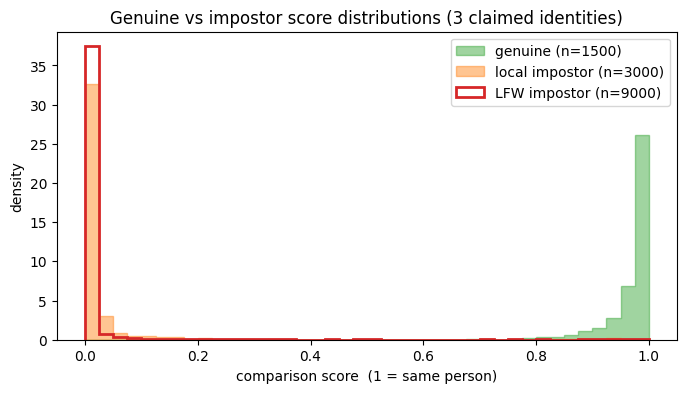

In [52]:
plt.figure(figsize=(8, 4))
bins = np.linspace(0, 1, 41)
plt.hist(genuine_scores, bins=bins, density=True, histtype='stepfilled', alpha=0.45,
         color='tab:green', edgecolor='tab:green', label=f'genuine (n={genuine_scores.size})')
if local_impostor_scores.size:
    plt.hist(local_impostor_scores, bins=bins, density=True, histtype='stepfilled', alpha=0.45,
             color='tab:orange', edgecolor='tab:orange', label=f'local impostor (n={local_impostor_scores.size})')
plt.hist(lfw_impostor_scores, bins=bins, density=True, histtype='step', linewidth=2,
         color='tab:red', label=f'LFW impostor (n={lfw_impostor_scores.size})')
plt.xlabel('comparison score  (1 = same person)')
plt.ylabel('density')
plt.title(f'Genuine vs impostor score distributions ({len(claimed_identities)} claimed identities)')
plt.legend()
plt.show()

## FMR / FNMR / DET / EER / d-prime (comparison level)
- FMR(t)  = impostor scores >= t  (impostors wrongly matched)
- FNMR(t) = genuine  scores <  t  (genuines wrongly rejected)

EER      = 1.054%  at threshold 0.794
d-prime  = 11.038  (higher = better separated)
At MATCH_THR=0.5: FMR=1.650% (198/12000), FNMR=0.000% (0/1500)


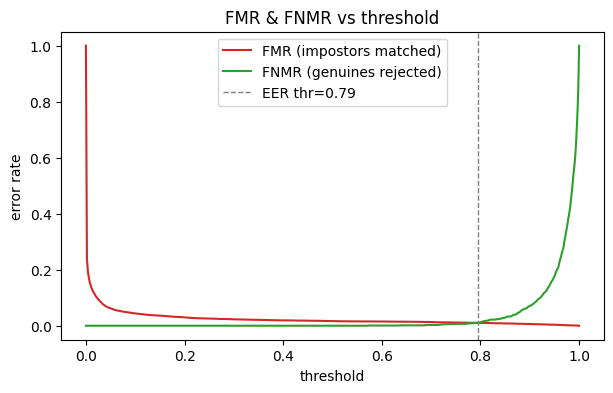

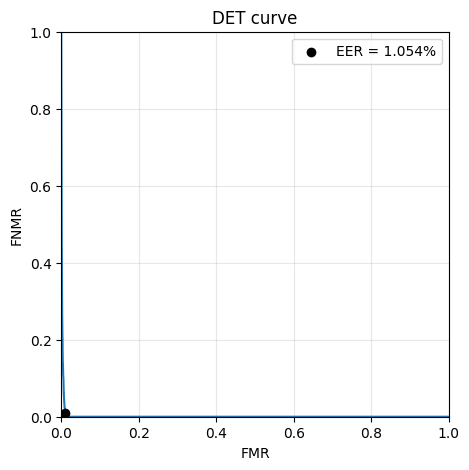

In [53]:
thresholds = np.linspace(0, 1, 501)
fmr = np.array([np.mean(impostor_scores >= t) for t in thresholds])
fnmr = np.array([np.mean(genuine_scores < t) for t in thresholds])
i = np.argmin(np.abs(fmr - fnmr))                 # EER: FMR ~= FNMR
eer, eer_thr = (fmr[i] + fnmr[i]) / 2, thresholds[i]
dprime = (genuine_scores.mean() - impostor_scores.mean()) / np.sqrt((genuine_scores.var() + impostor_scores.var()) / 2)
print(f'EER      = {eer:.3%}  at threshold {eer_thr:.3f}')
print(f"d-prime  = {dprime:.3f}  (higher = better separated)")
selected_fmr = np.mean(impostor_scores >= MATCH_THR)
selected_fnmr = np.mean(genuine_scores < MATCH_THR)
selected_fm = np.sum(impostor_scores >= MATCH_THR)
selected_fnm = np.sum(genuine_scores < MATCH_THR)
print(f'At MATCH_THR={MATCH_THR}: FMR={selected_fmr:.3%} ({selected_fm}/{impostor_scores.size}), '
      f'FNMR={selected_fnmr:.3%} ({selected_fnm}/{genuine_scores.size})')

# FMR & FNMR vs threshold
plt.figure(figsize=(7, 4))
plt.plot(thresholds, fmr, color='tab:red', label='FMR (impostors matched)')
plt.plot(thresholds, fnmr, color='tab:green', label='FNMR (genuines rejected)')
plt.axvline(eer_thr, ls='--', color='gray', lw=1, label=f'EER thr={eer_thr:.2f}')
plt.xlabel('threshold'); plt.ylabel('error rate')
plt.title('FMR & FNMR vs threshold'); plt.legend(); plt.show()

# DET-style error trade-off: FNMR vs FMR across thresholds
plt.figure(figsize=(5, 5))
plt.plot(fmr, fnmr, color='tab:blue')
plt.scatter([eer], [eer], color='k', zorder=5, label=f'EER = {eer:.3%}')
plt.xlabel('FMR'); plt.ylabel('FNMR'); plt.title('DET curve')
plt.xlim(0, 1); plt.ylim(0, 1); plt.grid(alpha=0.3); plt.legend(); plt.show()

## FAR / FRR (Application level)

operating point: MATCH_THR=0.5, DECISION_THR=0.6
Rates are application-level; local FAR uses other enrolled people as wrong claimants.
claim                          FRR         local FAR           LFW FAR      combined FAR
justin               0.000% (0/50)    0.000% (0/100)   3.333% (10/300)   2.500% (10/400)
lara                 0.000% (0/50)    1.000% (1/100)    0.000% (0/300)    0.250% (1/400)
tomas                0.000% (0/50)    0.000% (0/100)    0.000% (0/300)    0.000% (0/400)

Pooled FRR = 0.000% (0/150)
Pooled FAR = 0.917% (11/1200)
  local impostor FAR = 0.333% (1/300)
  LFW impostor FAR   = 1.111% (10/900)


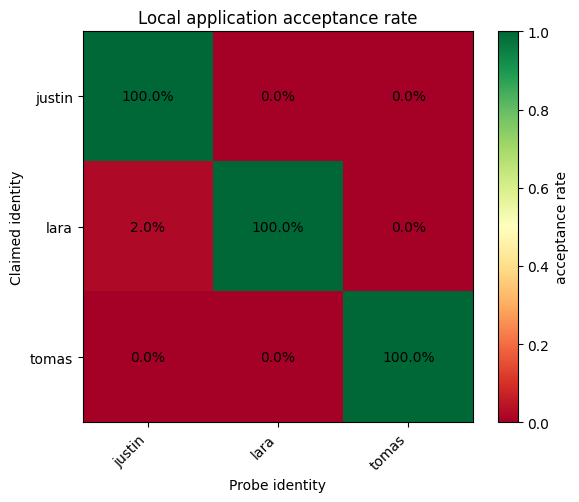

In [54]:
def rate_text(errors, trials):
    return f'{errors / trials:.3%} ({errors}/{trials})' if trials else 'n/a (0/0)'

print(f'operating point: MATCH_THR={MATCH_THR}, DECISION_THR={DECISION_THR}')
print('Rates are application-level; local FAR uses other enrolled people as wrong claimants.')
print(f'{"claim":<16}{"FRR":>18}{"local FAR":>18}{"LFW FAR":>18}{"combined FAR":>18}')

for claimed_identity in claimed_identities:
    result = evaluation_by_identity[claimed_identity]
    genuine = result['local'][claimed_identity]['decisions']
    local_impostors = concatenate_nonempty([
        result['local'][probe]['decisions']
        for probe in claimed_identities if probe != claimed_identity
    ], dtype=bool)
    lfw_impostors = result['lfw']['decisions']
    combined_impostors = concatenate_nonempty([local_impostors, lfw_impostors], dtype=bool)

    frr_text = rate_text(int((~genuine).sum()), genuine.size)
    local_far_text = rate_text(int(local_impostors.sum()), local_impostors.size)
    lfw_far_text = rate_text(int(lfw_impostors.sum()), lfw_impostors.size)
    combined_far_text = rate_text(int(combined_impostors.sum()), combined_impostors.size)
    print(f'{claimed_identity:<16}{frr_text:>18}{local_far_text:>18}{lfw_far_text:>18}{combined_far_text:>18}')

print(f'\nPooled FRR = {rate_text(int((~genuine_decisions).sum()), genuine_decisions.size)}')
print(f'Pooled FAR = {rate_text(int(impostor_decisions.sum()), impostor_decisions.size)}')
print(f'  local impostor FAR = {rate_text(int(local_impostor_decisions.sum()), local_impostor_decisions.size)}')
print(f'  LFW impostor FAR   = {rate_text(int(lfw_impostor_decisions.sum()), lfw_impostor_decisions.size)}')

if len(claimed_identities) > 1:
    acceptance_matrix = np.array([
        [evaluation_by_identity[claim]['local'][probe]['decisions'].mean()
         for probe in claimed_identities]
        for claim in claimed_identities
    ])
    fig, ax = plt.subplots(figsize=(6, 5))
    image = ax.imshow(acceptance_matrix, vmin=0, vmax=1, cmap='RdYlGn')
    ax.set_xticks(range(len(claimed_identities)), claimed_identities, rotation=45, ha='right')
    ax.set_yticks(range(len(claimed_identities)), claimed_identities)
    ax.set_xlabel('Probe identity')
    ax.set_ylabel('Claimed identity')
    ax.set_title('Local application acceptance rate')
    for row in range(len(claimed_identities)):
        for column in range(len(claimed_identities)):
            ax.text(column, row, f'{acceptance_matrix[row, column]:.1%}', ha='center', va='center')
    fig.colorbar(image, ax=ax, label='acceptance rate')
    plt.tight_layout()
    plt.show()
else:
    print('Local claim/probe matrix skipped because it requires at least two enrolled identities.')

## Inference latency

-  direct model call; no predict() Python/callback overhead

In [56]:
def bench(fn, n=50, warmup=10):
    """Warm up (discard graph tracing / first-call cost), then time n repeats -> ms array."""
    for _ in range(warmup):
        fn()
    t = np.empty(n)
    for k in range(n):
        t0 = time.perf_counter()
        fn()
        t[k] = (time.perf_counter() - t0) * 1e3   # ms
    return t

def summarize(name, timings):
    print(
        f'{name:28s} median={np.median(timings):6.2f}  mean={timings.mean():6.2f}  '
        f'p95={np.percentile(timings, 95):6.2f}  min={timings.min():6.2f}  '
        f'std={timings.std():5.2f} ms  (n={timings.size})'
    )

print(f'device: {"GPU" if tf.config.get_visible_devices("GPU") else "CPU"}')
transaction_timings = []
for claimed_identity in claimed_identities:
    result = evaluation_by_identity[claimed_identity]
    reference_batch = result['reference_batch']
    genuine_path = result['local'][claimed_identity]['paths'][0]
    reference_count = int(reference_batch.shape[0])
    probe_all = tf.repeat(
        tf.expand_dims(preprocess(genuine_path), 0), reference_count, axis=0
    )
    timings = bench(
        lambda probe_all=probe_all, reference_batch=reference_batch: model(
            [probe_all, reference_batch], training=False
        ),
        n=50,
    )
    transaction_timings.append(timings)
    summarize(f'{claimed_identity} transaction (R={reference_count})', timings)

# One comparison benchmark, independent of gallery size.
first_identity = claimed_identities[0]
first_result = evaluation_by_identity[first_identity]
one_a = tf.expand_dims(preprocess(first_result['local'][first_identity]['paths'][0]), 0)
one_b = first_result['reference_batch'][:1]
t_pair = bench(lambda: model([one_a, one_b], training=False), n=50)
summarize('1:1 comparison', t_pair)


device: GPU
justin transaction (R=10)    median= 16.51  mean= 16.38  p95= 17.43  min=  9.56  std= 1.45 ms  (n=50)
lara transaction (R=10)      median= 16.48  mean= 15.73  p95= 17.11  min=  5.77  std= 2.88 ms  (n=50)
tomas transaction (R=10)     median= 16.42  mean= 15.74  p95= 17.37  min=  5.96  std= 2.87 ms  (n=50)
1:1 comparison               median=  5.92  mean=  6.09  p95=  7.01  min=  5.75  std= 0.39 ms  (n=50)
